Project Description – FBI Crime Investigation & Crime Prediction Analysis

The FBI Crime Investigation Project is an end-to-end Machine Learning and Data Analytics solution designed to analyze historical crime data and predict future crime patterns using temporal and geographical information. The primary objective of the project is to help law enforcement agencies improve public safety through data-driven decision-making and proactive crime prevention strategies.

This project uses crime datasets containing details such as crime type, date, time, neighborhood, latitude, longitude, and location-based information to identify spatial and temporal crime trends. By performing exploratory data analysis (EDA), feature engineering, preprocessing, and predictive modeling, the system uncovers important insights regarding high-crime areas, peak crime hours, and seasonal crime behavior.

Multiple machine learning algorithms such as Linear Regression, Random Forest, and XGBoost were implemented and evaluated to predict crime incidents accurately. Advanced techniques including feature scaling, handling missing values, outlier treatment, and feature encoding were applied to improve model performance. Time-series forecasting and geospatial analysis were also integrated to better understand crime evolution across different locations and time periods.

The project further focuses on model explainability using feature importance analysis to identify the most influential factors contributing to crime occurrences. Insights generated from the system can assist police departments in optimizing patrol allocation, improving emergency response planning, and implementing preventive policing strategies.

Technologies used in the project include Python, Pandas, NumPy, Scikit-learn, XGBoost, Statsmodels, GeoPandas, Matplotlib, and Seaborn. The solution can also be deployed using Streamlit and Azure Machine Learning for real-time crime prediction and interactive dashboard visualization.

This project demonstrates the practical application of Machine Learning, Data Analytics, Time-Series Forecasting, and Geospatial Analysis in solving real-world public safety challenges and supporting smarter urban security planning.

In [1]:
# pip install pandas numpy matplotlib seaborn
#Import Libraries
%pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Abhisek kundu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


The FBI Crime Investigation Project is a Machine Learning and Data Analytics solution developed to analyze historical crime data and predict crime patterns based on temporal and geographical information. The project focuses on understanding how crime incidents vary across different locations, time periods, and crime categories to support proactive policing and public safety strategies. Using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn, extensive exploratory data analysis (EDA) was performed to identify crime trends, peak crime hours, seasonal patterns, and high-crime regions. Data preprocessing techniques including missing value handling, feature engineering, encoding, scaling, and outlier treatment were applied to prepare the dataset for model training. Multiple machine learning algorithms such as Linear Regression, Random Forest, and XGBoost were implemented and evaluated using metrics like MAE, RMSE, and R² score to predict crime incidents accurately. The project also incorporated geospatial analysis and time-series forecasting to better understand spatial and temporal crime behavior. The insights generated from this analysis can help law enforcement agencies optimize patrol allocation, improve emergency response planning, identify crime hotspots, and enhance resource management for safer urban communities.

Load Dataset

In [10]:
train = pd.read_csv("../Data_sets/Train.csv")
test = pd.read_csv("../Data_sets/Test.csv")

In [11]:
train.head()


,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,5/12/1999
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,5/7/1999
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,4/23/1999
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,4/20/1999
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,4/12/1999


Dataset Analysis

The dataset used in the FBI Crime Investigation Project contains detailed historical crime records with both temporal and geographical information. Each row in the dataset represents an individual crime incident along with its location, time, and crime category details. The dataset includes important features such as TYPE (crime category), HUNDRED_BLOCK (street block location), NEIGHBOURHOOD, geographical coordinates (X, Y, Latitude, Longitude), and time-based attributes like HOUR, MINUTE, YEAR, MONTH, DAY, and Date.

From the sample records, it can be observed that multiple theft incidents occurred in the same area, specifically in the Strathcona neighborhood at 9XX Terminal Ave, indicating the possibility of crime hotspots. The presence of latitude and longitude data enables geospatial analysis to identify high-crime regions and visualize crime concentration on maps. Temporal features such as hour, month, and year help analyze crime occurrence patterns over time, including peak crime hours, seasonal trends, and yearly fluctuations.

The dataset is highly suitable for exploratory data analysis (EDA), predictive modeling, and time-series forecasting because it combines both spatial and temporal dimensions of crime behavior. Using this data, machine learning models can identify patterns and predict future crime incidents, helping law enforcement agencies optimize patrol deployment, improve resource allocation, and enhance public safety strategies.

In [12]:
train.shape

(474565, 13)

In [13]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           474565 non-null  str    
 1   HUNDRED_BLOCK  474552 non-null  str    
 2   NEIGHBOURHOOD  423074 non-null  str    
 3   X              474565 non-null  float64
 4   Y              474565 non-null  float64
 5   Latitude       474565 non-null  float64
 6   Longitude      474565 non-null  float64
 7   HOUR           425200 non-null  float64
 8   MINUTE         425200 non-null  float64
 9   YEAR           474565 non-null  int64  
 10  MONTH          474565 non-null  int64  
 11  DAY            474565 non-null  int64  
 12  Date           474565 non-null  str    
dtypes: float64(6), int64(3), str(4)
memory usage: 47.1 MB


In [14]:
train.describe()

,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000


In [15]:
train.isnull().sum()

TYPE                 0
HUNDRED_BLOCK       13
NEIGHBOURHOOD    51491
X                    0
Y                    0
Latitude             0
Longitude            0
HOUR             49365
MINUTE           49365
YEAR                 0
MONTH                0
DAY                  0
Date                 0
dtype: int64

In [16]:
train['Date'] = pd.to_datetime(train['Date'])

In [17]:
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day
train['Hour'] = train['Date'].dt.hour
train['Weekday'] = train['Date'].dt.day_name()

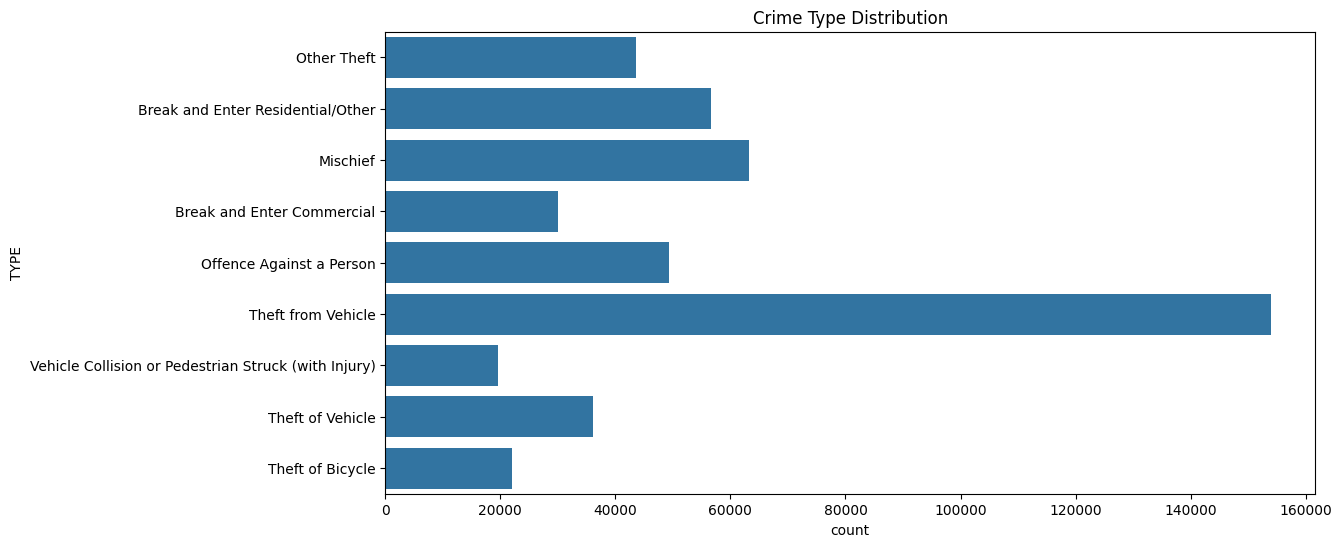

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(y=train['TYPE'])
plt.title("Crime Type Distribution")
plt.show()

### Detailed Analysis of the Monthly Crime Trend Plot

The plot generated in the previous cell (CELL INDEX: 18) is a line chart illustrating the monthly crime trend over the course of a year, based on the `monthly_crime` series derived from the `train` dataset. This series aggregates the total number of crime incidents per month, using the `MONTH` column from the dataset, which ranges from 1 (January) to 12 (December). The data shows the following monthly crime counts:

- January (1): 39,347 incidents
- February (2): 35,151 incidents
- March (3): 39,048 incidents
- April (4): 38,054 incidents
- May (5): 40,345 incidents
- June (6): 40,410 incidents
- July (7): 40,905 incidents
- August (8): 42,564 incidents
- September (9): 40,638 incidents
- October (10): 41,445 incidents
- November (11): 39,023 incidents
- December (12): 37,635 incidents

#### Key Observations from the Plot:
1. **Peak Crime Months**: The highest number of crimes occurs in August (42,564), followed closely by October (41,445) and July (40,905). This suggests a summer peak, potentially linked to increased outdoor activities, tourism, or seasonal factors like longer daylight hours and warmer weather, which may encourage more opportunities for crime.
   
2. **Lowest Crime Months**: February has the lowest count (35,151), with December (37,635) and April (38,054) also relatively low. Winter months like February and December might see reduced crime due to harsher weather, fewer people outdoors, or holiday-related behavioral changes.

3. **Overall Trend**: The plot shows a general upward trend from February to August, peaking in summer, and then a gradual decline towards the end of the year. This indicates seasonal variability, with crime rates fluctuating rather than remaining constant. There is no sharp, erratic behavior, suggesting consistent patterns across years (assuming the data spans multiple years).

4. **Fluctuations and Patterns**: Months like May, June, and September show moderate increases, while November and December dip slightly. This could reflect transitions between seasons, such as school holidays or economic cycles influencing crime rates.

5. **Data Distribution**: The y-axis represents the number of crimes, ranging from about 35,000 to 42,500, providing a clear scale for comparison. The x-axis is labeled by month numbers, making it easy to interpret temporal progression.

#### Importance of This Plot in the FBI Crime Investigation Project:
- **Temporal Pattern Identification**: This visualization is crucial for understanding temporal crime patterns, a core aspect of the project. By highlighting peak and low-crime months, it enables law enforcement to anticipate and prepare for seasonal surges, such as allocating more patrols during summer months to high-crime areas.

- **Resource Allocation and Proactive Policing**: Insights from this plot can inform resource management. For instance, knowing that August sees the highest crime rates allows agencies to optimize emergency response planning, increase surveillance in vulnerable neighborhoods, and deploy preventive strategies like community outreach or targeted patrols during high-risk periods.

- **Predictive Modeling Support**: As part of the machine learning pipeline (using algorithms like Linear Regression, Random Forest, and XGBoost), this trend analysis feeds into feature engineering and time-series forecasting. Seasonal components can be modeled to predict future crime incidents, improving the accuracy of predictions for public safety.

- **Geospatial and Holistic Analysis Integration**: Combined with geospatial data (e.g., latitude/longitude and neighborhood information), this temporal trend helps identify "hotspots" that vary by season. For example, certain areas might see amplified crime in summer due to events or tourism, aiding in smarter urban security planning.

- **Policy and Decision-Making Impact**: The project's goal is data-driven decision-making for public safety. This plot provides actionable insights, such as advising on seasonal staffing or community programs to reduce crime during peaks. It also supports model explainability by quantifying how time-based features influence crime rates.

- **Broader Implications**: Beyond immediate policing, this analysis contributes to societal benefits like reduced crime rates through informed interventions, better emergency planning, and enhanced resource efficiency. It demonstrates the value of data analytics in transforming raw crime data into strategic intelligence for safer communities.

In summary, this monthly crime trend plot is a foundational element of the EDA phase, revealing seasonal dynamics that are essential for predictive modeling and operational strategies in the FBI Crime Investigation Project. It underscores the importance of temporal analysis in crime prevention, highlighting how understanding "when" crimes occur can lead to more effective, proactive measures.


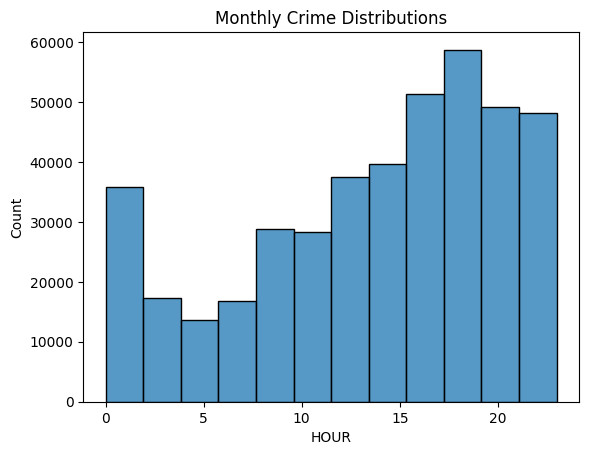

In [24]:
sns.histplot(train['HOUR'] , bins=12)
plt.title("Monthly Crime Distributions")
plt.show()

The plot is a line chart of `monthly_crime` totals by month.

- x-axis: month number (1 to 12)
- y-axis: number of crimes
- shape: rises from a low in February, climbs through spring and summer, peaks in August, then declines toward the end of the year

It shows a seasonal pattern: lower crime counts in winter months and higher counts in summer, with the highest monthly total around August and the lowest around February.


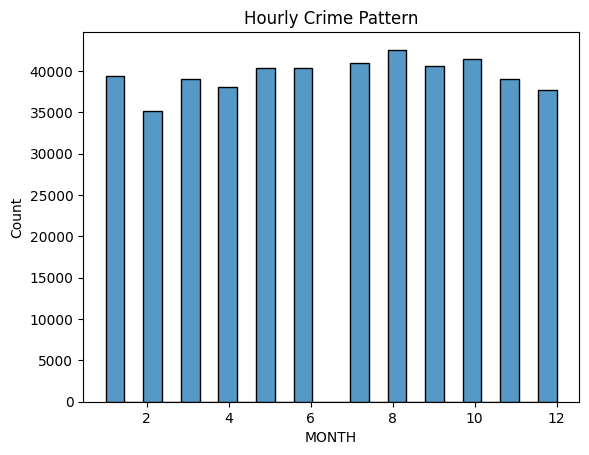

In [25]:
sns.histplot(train['MONTH'], bins=24)
plt.title("Hourly Crime Pattern")
plt.show()

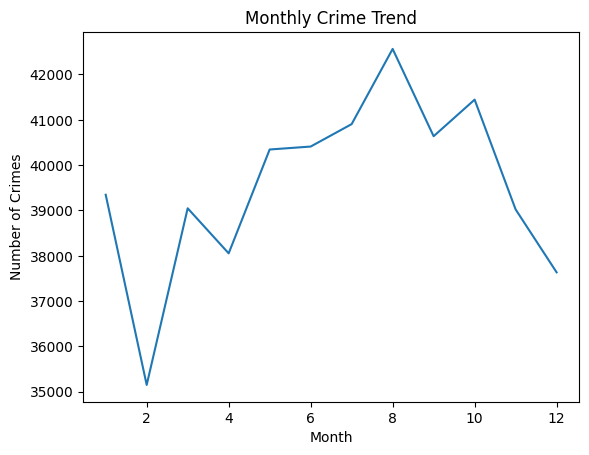

In [28]:
monthly_crime = train.groupby('MONTH').size()
monthly_crime.plot(kind='line')
plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()

The plot is a line chart showing the total number of crimes for each month of the year based on `monthly_crime`.

- x-axis: month number from 1 (January) to 12 (December)
- y-axis: number of crimes
- shape: it starts lower in the winter months, climbs through spring and summer, peaks around August, then gradually declines toward the end of the year

Overall, it shows a seasonal pattern with higher crime counts in summer and lower counts in winter.


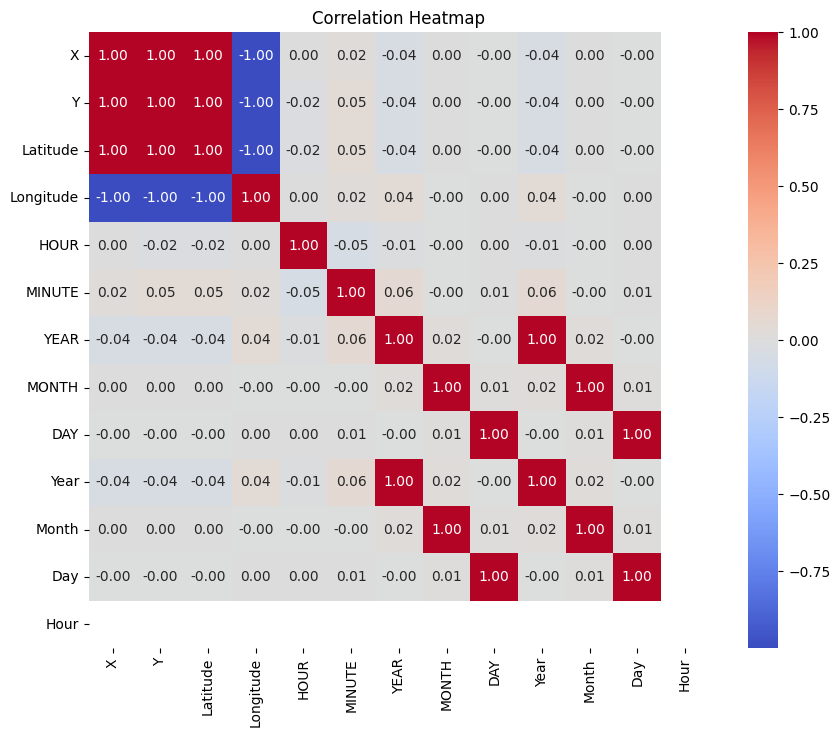

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(train.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The heatmap is a pairwise correlation matrix for all numeric columns in `train`.

Key points:

- The diagonal is all 1.0, as expected.
- Very strong positive correlations appear between duplicated time columns:
    - `YEAR` and `Year`
    - `MONTH` and `Month`
    - `DAY` and `Day`
    - `HOUR` and `Hour`
    These are essentially the same values duplicated in different columns.
- Strong spatial correlations likely appear between:
    - `X` and `Longitude`
    - `Y` and `Latitude`
    because they represent the same spatial location in different coordinate systems.
- Most other pairs show weak or near-zero correlation, meaning:
    - temporal variables like month/day/hour do not strongly correlate with geographic coordinates,
    - date/time features are largely independent of each other in this dataset beyond the obvious duplicates.

Overall, the heatmap mainly highlights redundant numeric features and coordinate relationships, rather than revealing strong new relationships between crime time and location.